In [3]:
# NOTEBOOK: Extraction Results Analysis
# Run this after: python src/extract.py --full

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# CELL 1: Load and Inspect Extraction Results

results_file = Path("../outputs/01_extraction_results.json")

with open(results_file) as f:
    extraction_data = json.load(f)


print("EXTRACTION RESULTS OVERVIEW")

# Metadata
metadata = extraction_data['metadata']
print(f"\nTimestamp: {metadata['timestamp']}")
print(f"Total Comments Processed: {metadata['total_comments']:,}")
print(f"Successful: {metadata['successful']:,} ({metadata['successful']/metadata['total_comments']*100:.1f}%)")
print(f"Failed: {metadata['failed']}")
print(f"\nTotal Aspects Extracted: {metadata['total_aspects']:,}")
print(f"Average Aspects per Comment: {metadata['avg_aspects_per_comment']:.2f}")

# Extract successful results
successful_results = [r for r in extraction_data['results'] if r['status'] == 'success']
failed_results = [r for r in extraction_data['results'] if r['status'] == 'error']

print('\n')
print(f"SUCCESS/FAILURE BREAKDOWN\n")

print(f"Successful extractions: {len(successful_results)}")
print(f"Failed extractions: {len(failed_results)}")

if failed_results:
    print(f"\nFailure reasons:")
    for result in failed_results[:5]:
        print(f"  - {result.get('error', 'Unknown error')}")

EXTRACTION RESULTS OVERVIEW

Timestamp: 2026-07-11T01:30:50.116637
Total Comments Processed: 5,000
Successful: 4,992 (99.8%)
Failed: 8

Total Aspects Extracted: 15,874
Average Aspects per Comment: 3.18


SUCCESS/FAILURE BREAKDOWN

Successful extractions: 4992
Failed extractions: 8

Failure reasons:
  - JSON parsing failed: Expecting ',' delimiter: line 18 column 56 (char 538)
  - JSON parsing failed: Expecting ',' delimiter: line 24 column 50 (char 1023)
  - JSON parsing failed: Expecting ',' delimiter: line 18 column 67 (char 752)
  - JSON parsing failed: Expecting ',' delimiter: line 18 column 42 (char 573)
  - JSON parsing failed: Expecting ',' delimiter: line 24 column 47 (char 855)


SENTIMENT DISTRIBUTION

Sentiment Distribution:
Sentiment  Count  Percentage
 positive   9039   56.942170
 negative   6552   41.275041
  neutral    282    1.776490
    mixed      1    0.006300


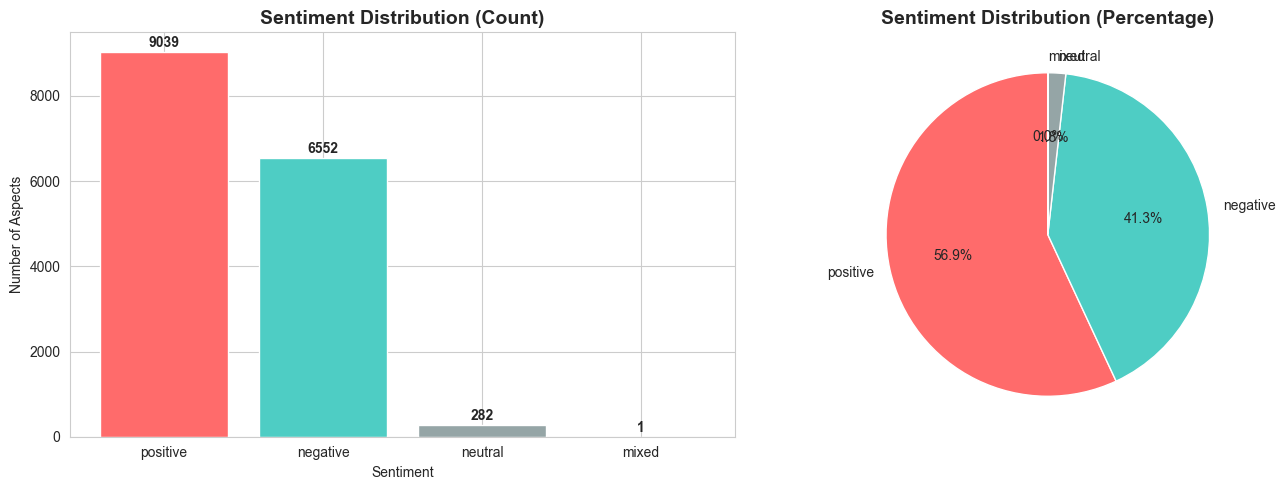


Total aspects: 15874


In [4]:
# CELL 2: Sentiment Distribution


print(f"SENTIMENT DISTRIBUTION")


all_aspects = []
sentiments = []
confidences = []

for result in successful_results:
    for aspect in result['extraction']['aspects']:
        all_aspects.append(aspect['aspect'])
        sentiments.append(aspect['sentiment'])
        confidences.append(aspect.get('confidence', 0.5))

sentiment_counts = Counter(sentiments)
sentiment_df = pd.DataFrame([
    {'Sentiment': sent, 'Count': count, 'Percentage': count/len(sentiments)*100}
    for sent, count in sentiment_counts.items()
])
sentiment_df = sentiment_df.sort_values('Count', ascending=False)

print("\nSentiment Distribution:")
print(sentiment_df.to_string(index=False))

# Plot 1: Sentiment Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(sentiment_df['Sentiment'], sentiment_df['Count'], color=['#ff6b6b', '#4ecdc4', '#95a5a6'])
axes[0].set_title('Sentiment Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Aspects')
axes[0].set_xlabel('Sentiment')
for i, v in enumerate(sentiment_df['Count']):
    axes[0].text(i, v + 100, str(int(v)), ha='center', fontweight='bold')

# Pie chart
colors = ['#ff6b6b', '#4ecdc4', '#95a5a6']
axes[1].pie(sentiment_df['Count'], labels=sentiment_df['Sentiment'], autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Sentiment Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal aspects: {len(sentiments)}")

CONFIDENCE SCORE ANALYSIS
Mean.......................... 0.9100
Median........................ 0.9200
Std........................... 0.0516
Min........................... 0.3000
Max........................... 0.9900
25th Percentile............... 0.9000
75th Percentile............... 0.9500


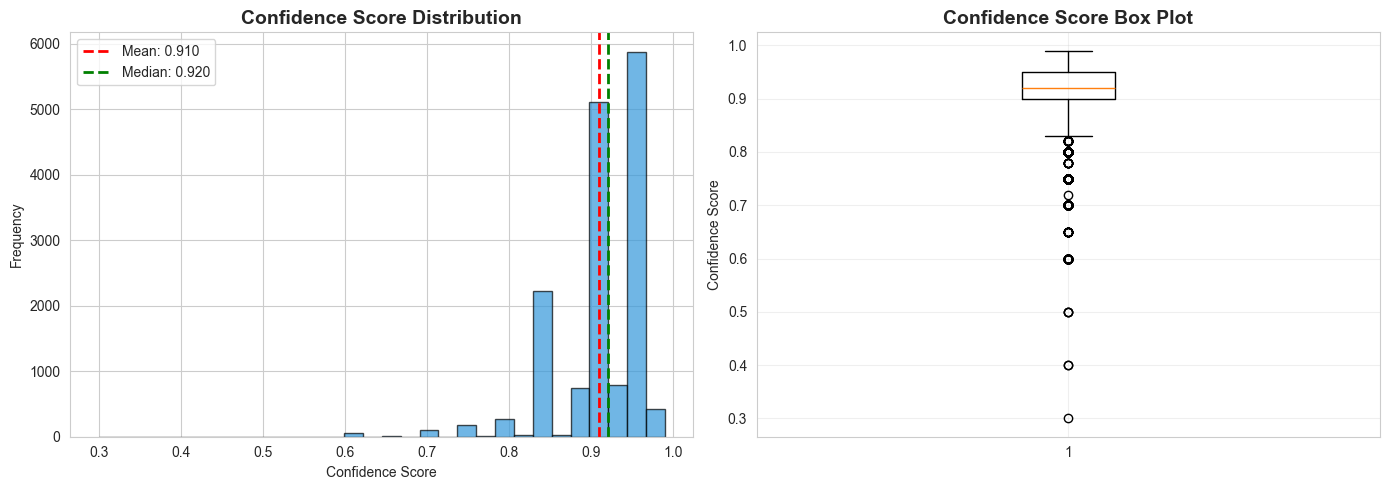

In [5]:
# CELL 3: Confidence Score Analysis

print(f"CONFIDENCE SCORE ANALYSIS")

conf_stats = {
    'Mean': np.mean(confidences),
    'Median': np.median(confidences),
    'Std': np.std(confidences),
    'Min': np.min(confidences),
    'Max': np.max(confidences),
    '25th Percentile': np.percentile(confidences, 25),
    '75th Percentile': np.percentile(confidences, 75),
}

for stat, value in conf_stats.items():
    print(f"{stat:.<30} {value:.4f}")

# Confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(confidences, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(confidences), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(confidences):.3f}')
axes[0].axvline(np.median(confidences), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(confidences):.3f}')
axes[0].set_title('Confidence Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(confidences, vert=True)
axes[1].set_title('Confidence Score Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Confidence Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

TOP 20 MOST COMMON ASPECTS
                         Aspect  Count  Percentage
                    Ease of use    311    1.959179
        Overall service quality    231    1.455210
            Overall app quality    201    1.266221
        Overall product quality    173    1.089832
Overall product/service quality    103    0.648860
       Customer service quality     91    0.573264
Customer support responsiveness     78    0.491370
          Overall functionality     73    0.459871
                Service quality     73    0.459871
     User interface ease of use     64    0.403175
        App login functionality     56    0.352778
                App ease of use     55    0.346479
         Overall app experience     50    0.314980
   Money transfer functionality     49    0.308681
Overall banking service quality     48    0.302381
            Login functionality     47    0.296082
                  App usability     46    0.289782
                    Convenience     46    0.289782
   O

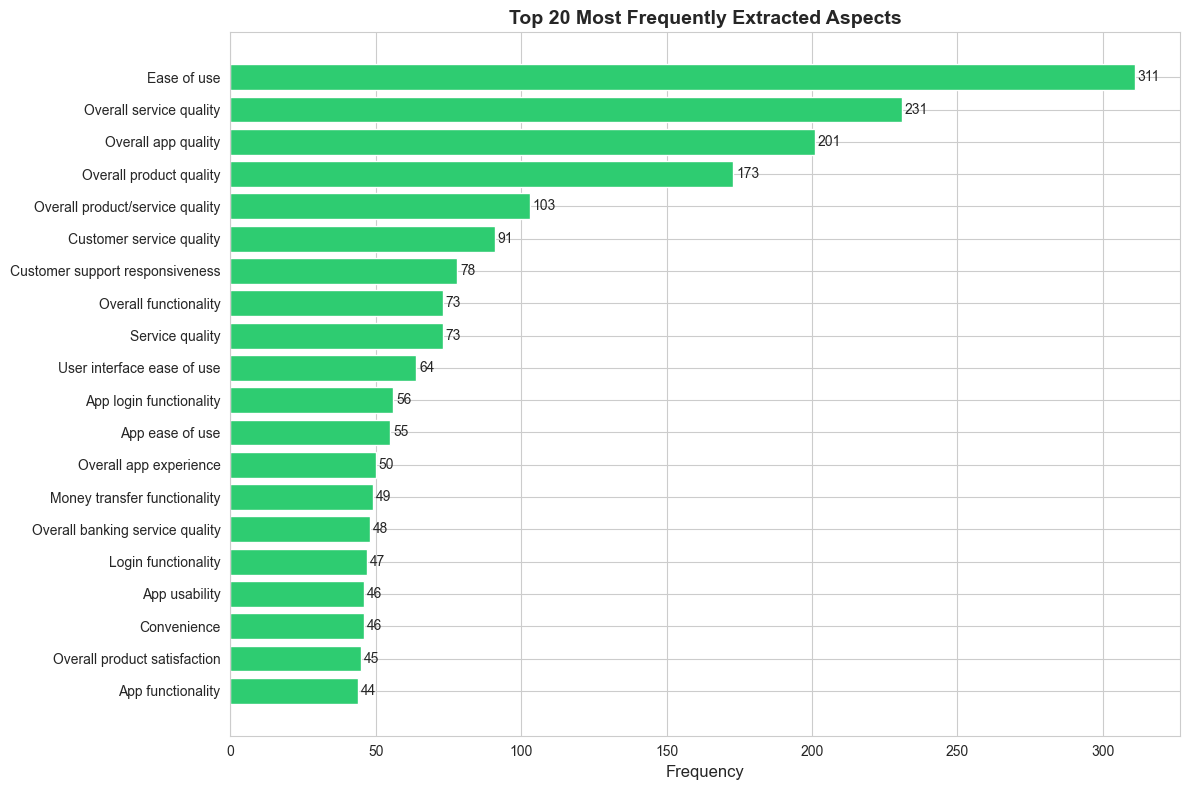

In [6]:
# CELL 4: Top Aspects by Frequency

print(f"TOP 20 MOST COMMON ASPECTS")

aspect_counts = Counter(all_aspects)
top_20_aspects = aspect_counts.most_common(20)

top_aspects_df = pd.DataFrame([
    {'Aspect': aspect, 'Count': count, 'Percentage': count/len(all_aspects)*100}
    for aspect, count in top_20_aspects
])

print(top_aspects_df.to_string(index=False))

# Plot top aspects
fig, ax = plt.subplots(figsize=(12, 8))
aspects_list = [a[0] for a in top_20_aspects]
counts_list = [a[1] for a in top_20_aspects]

ax.barh(range(len(aspects_list)), counts_list, color='#2ecc71')
ax.set_yticks(range(len(aspects_list)))
ax.set_yticklabels(aspects_list)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 20 Most Frequently Extracted Aspects', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(counts_list):
    ax.text(v + 1, i, str(v), va='center')

plt.tight_layout()
plt.show()

SENTIMENT BREAKDOWN FOR TOP 10 ASPECTS


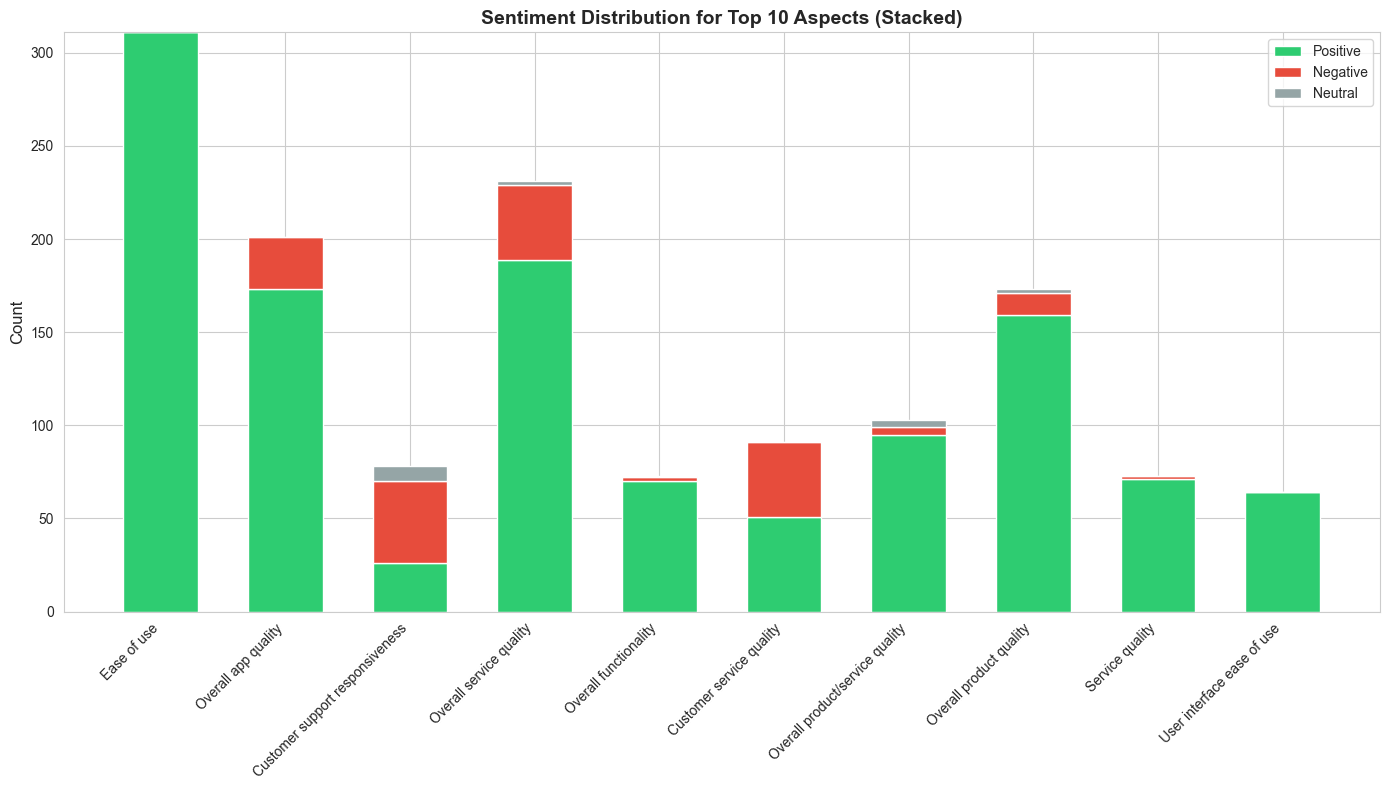


Sentiment breakdown by aspect:

Ease of use
  Positive: 311 (100.0%)
  Negative: 0 (0.0%)
  Neutral:  0 (0.0%)

Overall app quality
  Positive: 173 (86.1%)
  Negative: 28 (13.9%)
  Neutral:  0 (0.0%)

Customer support responsiveness
  Positive: 26 (33.3%)
  Negative: 44 (56.4%)
  Neutral:  8 (10.3%)

Overall service quality
  Positive: 189 (81.8%)
  Negative: 40 (17.3%)
  Neutral:  2 (0.9%)

Overall functionality
  Positive: 70 (95.9%)
  Negative: 2 (2.7%)
  Neutral:  1 (1.4%)

Customer service quality
  Positive: 51 (56.0%)
  Negative: 40 (44.0%)
  Neutral:  0 (0.0%)

Overall product/service quality
  Positive: 95 (92.2%)
  Negative: 4 (3.9%)
  Neutral:  4 (3.9%)

Overall product quality
  Positive: 159 (91.9%)
  Negative: 12 (6.9%)
  Neutral:  2 (1.2%)

Service quality
  Positive: 71 (97.3%)
  Negative: 2 (2.7%)
  Neutral:  0 (0.0%)

User interface ease of use
  Positive: 64 (100.0%)
  Negative: 0 (0.0%)
  Neutral:  0 (0.0%)


In [7]:
# CELL 5: Sentiment by Top Aspects

print(f"SENTIMENT BREAKDOWN FOR TOP 10 ASPECTS")

top_10_aspects = [a[0] for a in top_20_aspects[:10]]

sentiment_by_aspect = {}
for aspect, sentiment in zip(all_aspects, sentiments):
    if aspect in top_10_aspects:
        if aspect not in sentiment_by_aspect:
            sentiment_by_aspect[aspect] = Counter()
        sentiment_by_aspect[aspect][sentiment] += 1

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))

aspects_for_plot = list(sentiment_by_aspect.keys())
positive_counts = [sentiment_by_aspect[a].get('positive', 0) for a in aspects_for_plot]
negative_counts = [sentiment_by_aspect[a].get('negative', 0) for a in aspects_for_plot]
neutral_counts = [sentiment_by_aspect[a].get('neutral', 0) for a in aspects_for_plot]

x = np.arange(len(aspects_for_plot))
width = 0.6

ax.bar(x, positive_counts, width, label='Positive', color='#2ecc71')
ax.bar(x, negative_counts, width, bottom=positive_counts, label='Negative', color='#e74c3c')
ax.bar(x, neutral_counts, width, bottom=np.array(positive_counts)+np.array(negative_counts), 
       label='Neutral', color='#95a5a6')

ax.set_ylabel('Count', fontsize=12)
ax.set_title('Sentiment Distribution for Top 10 Aspects (Stacked)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(aspects_for_plot, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

# Print table
print("\nSentiment breakdown by aspect:")
for aspect in aspects_for_plot:
    pos = sentiment_by_aspect[aspect].get('positive', 0)
    neg = sentiment_by_aspect[aspect].get('negative', 0)
    neu = sentiment_by_aspect[aspect].get('neutral', 0)
    total = pos + neg + neu
    print(f"\n{aspect}")
    print(f"  Positive: {pos} ({pos/total*100:.1f}%)")
    print(f"  Negative: {neg} ({neg/total*100:.1f}%)")
    print(f"  Neutral:  {neu} ({neu/total*100:.1f}%)")

ASPECTS PER COMMENT ANALYSIS
Mean.......................... 3.18
Median........................ 3.00
Std Dev....................... 1.81
Min........................... 0.00
Max........................... 14.00


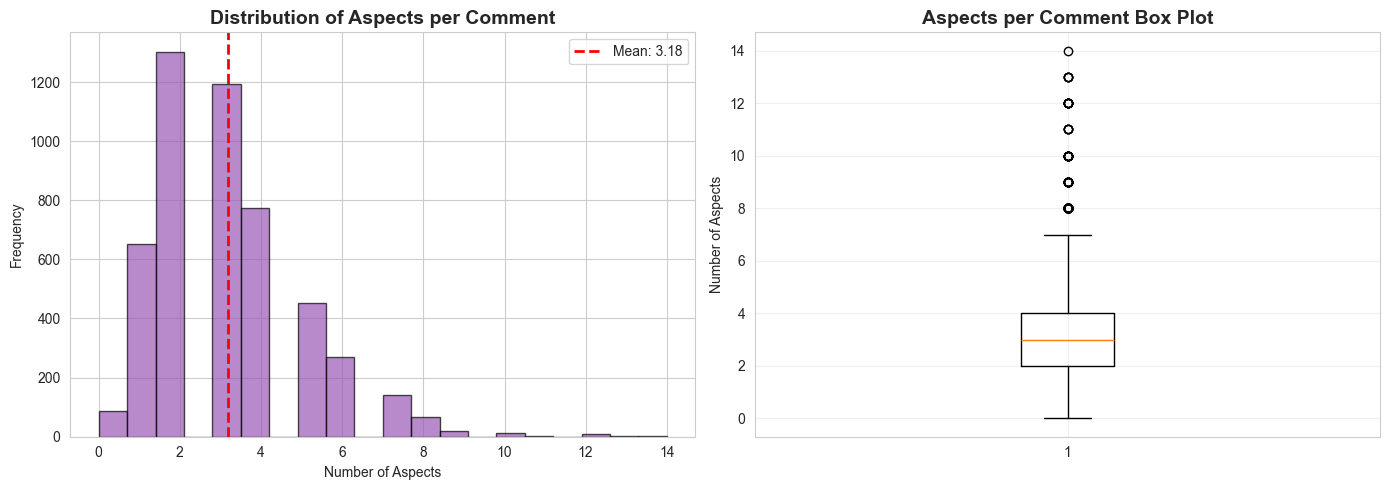

In [8]:
# CELL 6: Aspects per Comment Distribution

print(f"ASPECTS PER COMMENT ANALYSIS")

aspects_per_comment = [r['num_aspects'] for r in successful_results]

apc_stats = {
    'Mean': np.mean(aspects_per_comment),
    'Median': np.median(aspects_per_comment),
    'Std Dev': np.std(aspects_per_comment),
    'Min': np.min(aspects_per_comment),
    'Max': np.max(aspects_per_comment),
}

for stat, value in apc_stats.items():
    print(f"{stat:.<30} {value:.2f}")

# Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(aspects_per_comment, bins=20, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(aspects_per_comment), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(aspects_per_comment):.2f}')
axes[0].set_title('Distribution of Aspects per Comment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Aspects')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(aspects_per_comment, vert=True)
axes[1].set_title('Aspects per Comment Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Aspects')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


COST ANALYSIS
Input Tokens: 1,890,328
Output Tokens: 918,764
Total Tokens: 2,809,092

Input Cost: $1.5123
Output Cost: $3.6751
Total Cost: $5.1873

Cost per Aspect: $0.000327
Cost per Comment: $0.0010


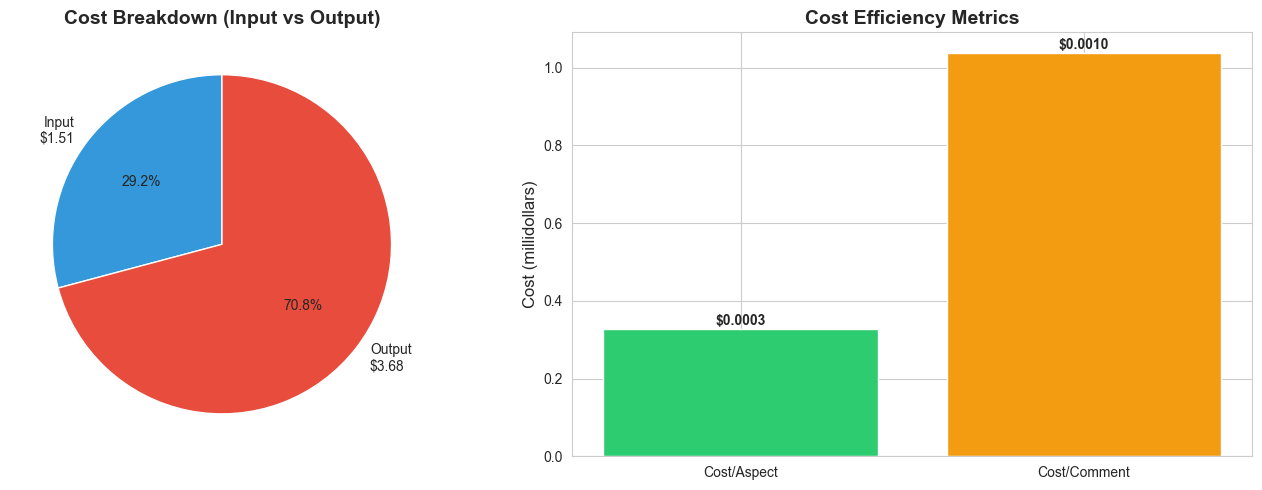

In [9]:
# ============================================================================
# CELL 7: Cost Summary
# ============================================================================

print(f"\n" + "=" * 80)
print(f"COST ANALYSIS")
print(f"=" * 80)

cost = metadata['cost_summary']
print(f"Input Tokens: {cost['input_tokens']:,}")
print(f"Output Tokens: {cost['output_tokens']:,}")
print(f"Total Tokens: {cost['total_tokens']:,}")
print(f"\nInput Cost: ${cost['input_cost_usd']:.4f}")
print(f"Output Cost: ${cost['output_cost_usd']:.4f}")
print(f"Total Cost: ${cost['total_cost_usd']:.4f}")
print(f"\nCost per Aspect: ${cost['total_cost_usd']/len(all_aspects):.6f}")
print(f"Cost per Comment: ${cost['total_cost_usd']/len(successful_results):.4f}")

# Plot costs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of input vs output
costs = [cost['input_cost_usd'], cost['output_cost_usd']]
labels = [f"Input\n${cost['input_cost_usd']:.2f}", f"Output\n${cost['output_cost_usd']:.2f}"]
axes[0].pie(costs, labels=labels, autopct='%1.1f%%', colors=['#3498db', '#e74c3c'], startangle=90)
axes[0].set_title('Cost Breakdown (Input vs Output)', fontsize=14, fontweight='bold')

# Cost efficiency
metrics = ['Cost/Aspect', 'Cost/Comment']
values = [
    cost['total_cost_usd']/len(all_aspects) * 1000,  # in millidollars for readability
    cost['total_cost_usd']/len(successful_results) * 1000
]
axes[1].bar(metrics, values, color=['#2ecc71', '#f39c12'])
axes[1].set_ylabel('Cost (millidollars)', fontsize=12)
axes[1].set_title('Cost Efficiency Metrics', fontsize=14, fontweight='bold')
for i, v in enumerate(values):
    axes[1].text(i, v + 0.01, f'${v/1000:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [10]:
# CELL 8: Summary Statistics

print(f"FINAL SUMMARY STATISTICS")

summary = {
    'Total Comments': len(successful_results),
    'Total Aspects': len(all_aspects),
    'Unique Aspects': len(aspect_counts),
    'Avg Aspects/Comment': len(all_aspects) / len(successful_results),
    'Avg Confidence': np.mean(confidences),
    'Positive %': (sentiments.count('positive') / len(sentiments) * 100),
    'Negative %': (sentiments.count('negative') / len(sentiments) * 100),
    'Neutral %': (sentiments.count('neutral') / len(sentiments) * 100),
    'Total Cost': f"${cost['total_cost_usd']:.2f}",
    'Budget Remaining': f"${20.00 - cost['total_cost_usd']:.2f}"
}

for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key:.<40} {value:.2f}")
    else:
        print(f"{key:.<40} {value}")

FINAL SUMMARY STATISTICS
Total Comments.......................... 4992
Total Aspects........................... 15874
Unique Aspects.......................... 9692
Avg Aspects/Comment..................... 3.18
Avg Confidence.......................... 0.91
Positive %.............................. 56.94
Negative %.............................. 41.28
Neutral %............................... 1.78
Total Cost.............................. $5.19
Budget Remaining........................ $14.81
